## Практика. Регуляризация

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

>#### Задание 1
Прочитайте файл `hr`.

In [2]:
df = pd.read_csv('data/hr.csv')
print(df) 

    Age  Experience  Gender  HigherEd  English  Python  SQL  R  Conferences  \
0    59           4       0         1        3       3    3  4            1   
1    49           2       0         0        2       3    3  3            1   
2    35           4       1         1        1       1    2  3            2   
3    28           0       1         1        1       4    1  3            0   
4    41           1       0         1        2       2    4  2            0   
5    59           3       1         1        1       4    2  4            0   
6    39           0       1         1        1       2    2  4            1   
7    43           3       1         1        3       0    3  2            0   
8    31           1       1         1        1       2    3  2            4   
9    31           1       1         1        1       3    3  2            0   
10   44           0       1         1        1       3    2  2            0   
11   56           1       1         1        3      

#### Контекст

Нам надоело работать младшими научными сотрудниками. Мы хотим работать датасайентистами и зарабатывать огромный деньги. Каким-то образом нам удалось раздобыть небольшой фрагмент о сосискателях с оценками эйчаров.

#### Датасет

- Age — возраст (int),
- Experience — опыт работы датасайентистом (int),
- Gender — пол (0 — женщина, 1 — мужчина) (int),
- HigherEd — высшее образование (0 — нет, 1 — есть) (int),
- English — самооценка уровня владения по трехбалльной шкале (int),
- Python — самооценка навыков по пятибалльной шкале (int),
- SQL — самооценка навыков по пятибалльной шкале (int),
- R — самооценка навыков по пятибалльной шкале (int),
- Conferences — число участий в профильных конференциях за последние 5 лет (int),
- Publications — число публикаций в профильных изданиях за последние 5 лет (int),
- Certificates — число сертификатов о дополнительном образовании по профилю (int),
- WeekendWork — готовность работать в выходные (0 — нет, 1 — да) (int),
- Overtime — готовность к переработкам (0 — нет, 1 — да) (int),
- Actual — зарплата на последнем месте работы (в тысячах рублей) (float),
- Desired — желаемая зарплата (в тысячах рублей) (float),
- Relocate — готовность к переезду (0 — нет, 1 — да) (int).

#### Таргет

- Target — оценка эйчара по стобалльной шкале (int).

#### Бизнес-задача

Выяснить, какие факторы являются наиболее значимыми с точки зрения эйчара. В течение ближайшего времени усилить важные факторы. Трудоустроиться датасайентистом. Получать большую зарплату. Умереть счачстливым.

>#### Задание 2
Обучите base-line-модель LinearRegression. На ста запусках выясните, есть ли эффект переобучения.

In [3]:
X = df.drop(columns = ['Target'])
y = df['Target']

r2_train_lr = [] 
r2_test_lr = [] 

for k in range(100):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=k)
    
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    y_train_pred_lr = lr.predict(X_train)
    y_test_pred_lr = lr.predict(X_test)

    r2_train_lr.append(r2_score(y_train, y_train_pred_lr))
    r2_test_lr.append(r2_score(y_test, y_test_pred_lr))
    
print('r2_train =', round(np.array(r2_train_lr).mean(), 4))
print('r2_test  =', round(np.array(r2_test_lr).mean(), 4))

r2_train = 0.9912
r2_test  = 0.7844


Ну... не факт, что переобучение есть. Скор на test'е упал по сравнению с train'ом, но не сильно.

>#### Задание 3
Визуализируйте распределения коэффициентов модели при помощи ящиков с усами. Какие коэффициенты являются самыми значимыми? Какой должна быть стратегия работы с резюме для успешного трудоустройства?

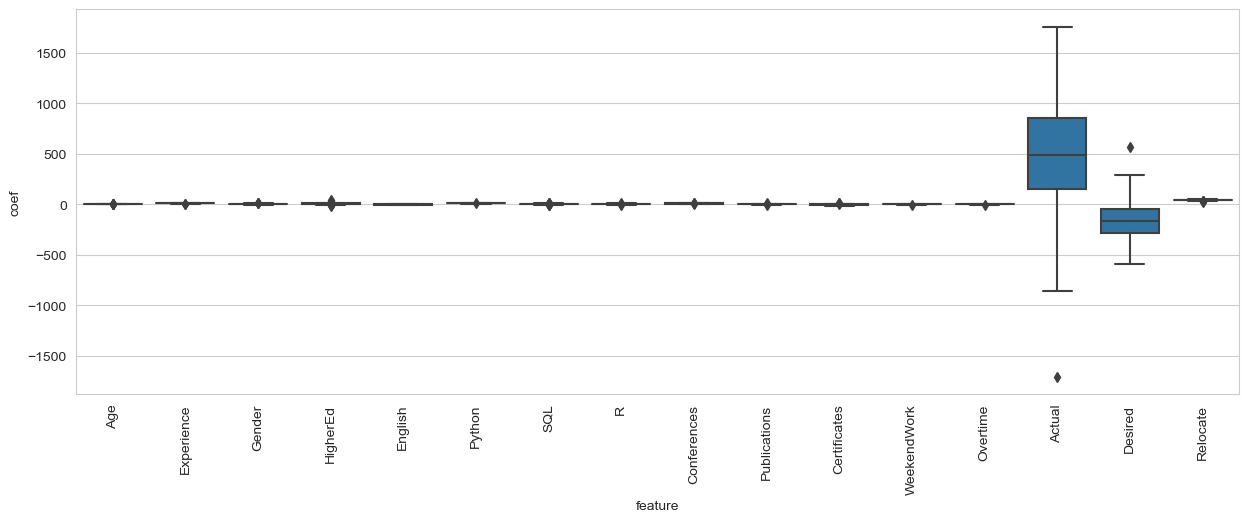

Age              -0.277775
Experience       10.429692
Gender            2.897509
HigherEd          8.021458
English          -1.440062
Python           10.787842
SQL               3.147553
R                 2.158294
Conferences       8.062872
Publications      2.098844
Certificates     -2.143594
WeekendWork       0.522576
Overtime          0.522576
Actual          470.655094
Desired        -156.906125
Relocate         43.966801
dtype: float64


In [4]:
X = df.drop(columns = ['Target'])
y = df['Target']

coef_lr = pd.DataFrame(columns = X.columns)

for k in range(100):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=k)
    
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    coef_lr.loc[k] = lr.coef_

coef_long_lr = pd.DataFrame(columns = ['feature', 'coef'])
for col in coef_lr.columns:
    d = pd.DataFrame(columns = ['feature', 'coef'])
    d['feature'] = [col]*len(coef_lr)
    d['coef'] = coef_lr[col]
    coef_long_lr = pd.concat([coef_long_lr, d], ignore_index=True)
    
plt.figure(figsize=(15, 5))
sns.boxplot(data=coef_long_lr, x='feature', y='coef', color = 'C0')
plt.xticks(rotation=90)
plt.show()

print(coef_lr.mean())

Судя по таким поэффициентам, самыми главними являются зарплаты: актуальная и желаемая. А с учетом их знаков, нужно в резюме указать актуальную зарплату побольше, а желаемую — поменьше. И в этом емть определенная логика: может, именно так выглядит идеальный кандидат с точки зрения эйчара?

>#### Задание 4
Подберите оптимальный параметр регуляризации Ridge. Для каждого значения параметра используйте 100 запусков.

In [5]:
max_r2_train_ridge = 0
max_r2_test_ridge = 0
max_alpha_ridge = 0

alpha_list = np.arange(0.01, 1.5, 0.1)

for alpha in alpha_list:

    r2_train_ridge = []
    r2_test_ridge =[]

    for k in range(100):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=k)
        
        ridge = Ridge(alpha)
        ridge.fit(X_train, y_train)

        y_train_pred_ridge = ridge.predict(X_train)
        y_test_pred_ridge = ridge.predict(X_test)

        r2_train_ridge.append(r2_score(y_train, y_train_pred_ridge))
        r2_test_ridge.append(r2_score(y_test, y_test_pred_ridge))
    
    if np.array(r2_test_ridge).mean() > max_r2_test_ridge:
        max_alpha_ridge = alpha
        max_r2_train_ridge = np.array(r2_train_ridge).mean()
        max_r2_test_ridge = np.array(r2_test_ridge).mean()
        
           
#     print(round(alpha, 2))

print('alpha =', max_alpha_ridge)
print('max_r2_train =', max_r2_train_ridge)
print('max_r2_test =', max_r2_test_ridge)

print('')

alpha = 0.11
max_r2_train = 0.9880413866369078
max_r2_test = 0.8189508520250641



Скор на ntsn'е вырос по сравнению с LinearRegression. Стало быть, переобучение все-таки было. Оптимальное alpha = 0.11.

>#### Задание 5
Проведите 100 запусков регрессии Ridge и визуализируйте распределение коэффициентов при помощи ящиков с усами. Какие коэффициенты являются самыми значимыми? Можно ли доверять интерпертации таких коэффициентов?

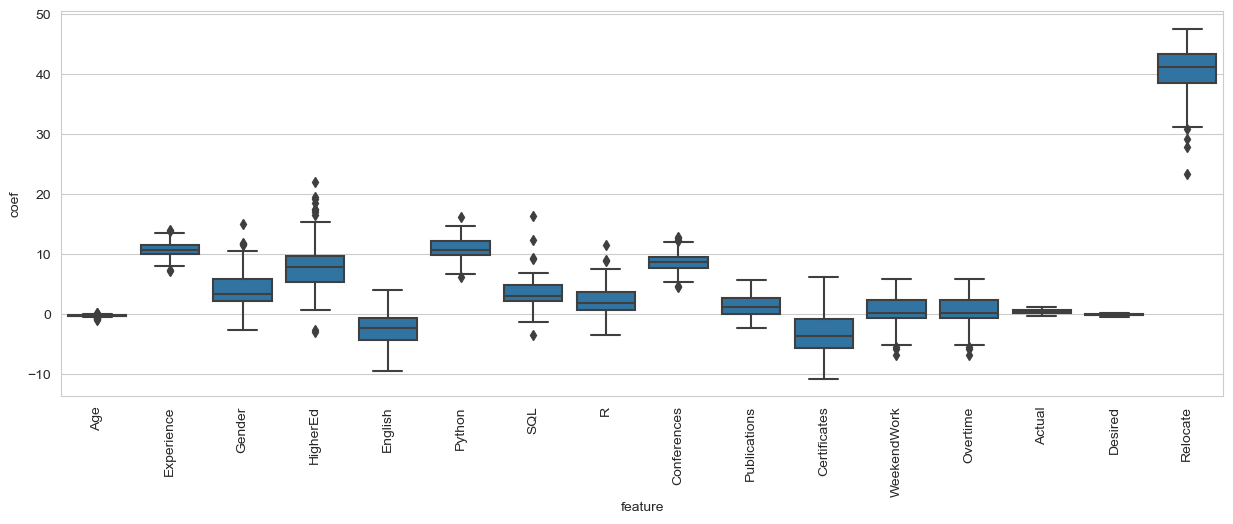

Age             -0.275211
Experience      10.850461
Gender           4.205090
HigherEd         8.279870
English         -2.296181
Python          10.890354
SQL              3.488230
R                2.378642
Conferences      8.602661
Publications     1.387439
Certificates    -3.213525
WeekendWork      0.537786
Overtime         0.537786
Actual           0.410575
Desired         -0.162317
Relocate        40.436133
dtype: float64


In [6]:
X = df.drop(columns = ['Target'])
y = df['Target']

coef_ridge = pd.DataFrame(columns = X.columns)

for k in range(100):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=k)
    
    ridge = Ridge(max_alpha_ridge)
    ridge.fit(X_train, y_train)

    coef_ridge.loc[k] = ridge.coef_

coef_long_ridge = pd.DataFrame(columns = ['feature', 'coef'])
for col in coef_ridge.columns:
    d = pd.DataFrame(columns = ['feature', 'coef'])
    d['feature'] = [col]*len(coef_lr)
    d['coef'] = coef_ridge[col]
    coef_long_ridge = pd.concat([coef_long_ridge, d], ignore_index=True)
    
plt.figure(figsize=(15, 5))
sns.boxplot(data=coef_long_ridge, x='feature', y='coef', color = 'C0')
plt.xticks(rotation=90)
plt.show()

print(coef_ridge.mean())

Так. Величины коэффициентов стали более правдоподобными. Актуальная и желаемая зарплаты оказались вообще не значимыми.  Но верить в такие значимости по-прежнему нельзя. Потому что предикторы не нормализованы. Релокация принимает значения 0 и 1. Чтобы преобразовать ее вклад в стобалльную шкалу таргета, нужен большой коэффициент. А опыт работы — от 0 до 10. Ему достаточно меньшего коэффициента для значительного вклада.

Чтобы оценить реальный вклад, и иметь возможность корректно сравнивать вклады различных предикторов, нужно привести все предикторы к единому масштабу. Поскольку большинство предикторов — это оценки, разумно применить минимакс.

>#### Задание 6
Проведите нормализацию предикторов по минимаксу. Интерпретируйте коэффициенты регрессии. Какой должна быть стратегия трудоустройства?

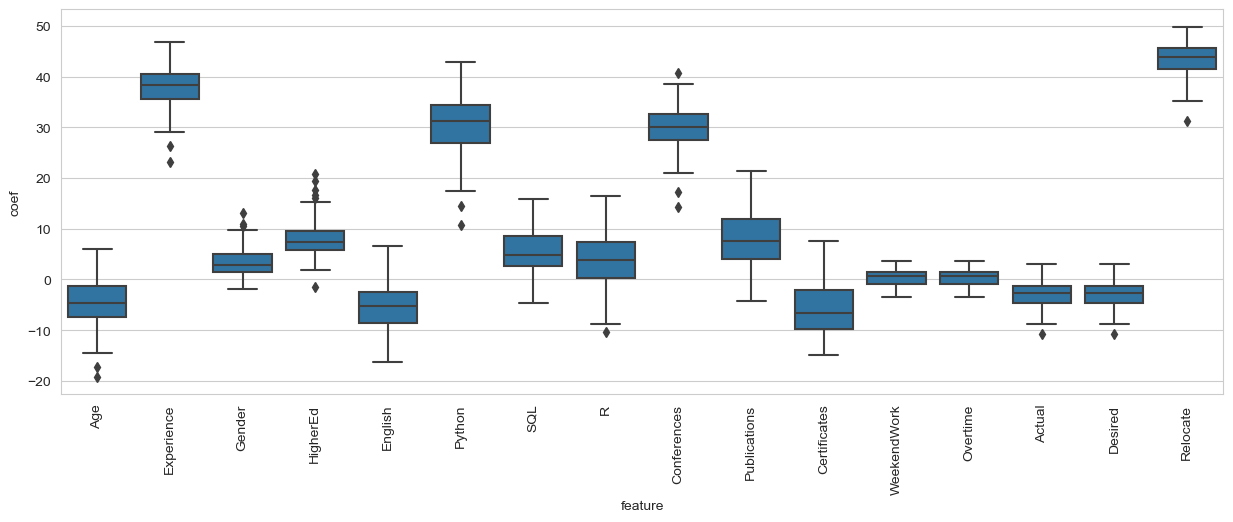

Age             -4.549538
Experience      38.052920
Gender           3.489116
HigherEd         8.007957
English         -5.428793
Python          30.470596
SQL              5.064604
R                3.927329
Conferences     29.739738
Publications     8.096518
Certificates    -5.866450
WeekendWork      0.443154
Overtime         0.443154
Actual          -2.885389
Desired         -2.891117
Relocate        43.270464
dtype: float64


In [7]:
X = df.drop(columns = ['Target'])
y = df['Target']

coef_ridge = pd.DataFrame(columns = X.columns)

for k in range(100):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=k)
    
    scaler = MinMaxScaler()
    scaler.fit(X_train)

    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
    
    ridge = Ridge(max_alpha_ridge)
    ridge.fit(X_train, y_train)

    coef_ridge.loc[k] = ridge.coef_

coef_long_ridge = pd.DataFrame(columns = ['feature', 'coef'])
for col in coef_ridge.columns:
    d = pd.DataFrame(columns = ['feature', 'coef'])
    d['feature'] = [col]*len(coef_lr)
    d['coef'] = coef_ridge[col]
    coef_long_ridge = pd.concat([coef_long_ridge, d], ignore_index=True)
    
plt.figure(figsize=(15, 5))
sns.boxplot(data=coef_long_ridge, x='feature', y='coef', color = 'C0')
plt.xticks(rotation=90)
plt.show()

print(coef_ridge.mean())

Вот теперь — все корректно. Значимые предикторы: опыт работы, знание Python, участие в конференциях и готовность к переезду. Опыт работы быстро получить не получится. Сильно повысить знания Python — тоже быстро не получится. А нам надо быстро. Но вот набрать несколько конференций за пару месяцев — реально. И переехать в Москву — тоже реально. 

Стратегия такая: переезжаем в Москву и участвуем в конференциях.

>#### Задание 6
Подберите оптимальный параметр регуляризации Lasso. Для каждого значения параметра используйте 100 запусков.

In [8]:
max_r2_train_lasso = 0
max_r2_test_lasso = 0
max_alpha_lasso = 0

alpha_list = np.arange(0.01, 1.5, 0.1)

for alpha in alpha_list:

    r2_train_lasso = []
    r2_test_lasso =[]

    for k in range(100):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=k)
        
        lasso = Lasso(alpha)
        lasso.fit(X_train, y_train)

        y_train_pred_lasso = lasso.predict(X_train)
        y_test_pred_lasso = lasso.predict(X_test)

        r2_train_lasso.append(r2_score(y_train, y_train_pred_lasso))
        r2_test_lasso.append(r2_score(y_test, y_test_pred_lasso))
    
    if np.array(r2_test_lasso).mean() > max_r2_test_lasso:
        max_alpha_lasso = alpha
        max_r2_train_lasso = np.array(r2_train_lasso).mean()
        max_r2_test_lasso = np.array(r2_test_lasso).mean()
        
           
#     print(round(alpha, 2))

print('alpha =', round(max_alpha_lasso, 2))
print('max_r2_train =', max_r2_train_lasso)
print('max_r2_test =', max_r2_test_lasso)

print('')

alpha = 0.31
max_r2_train = 0.9830278799770599
max_r2_test = 0.8624702186674837



Ну... с одной стороны здесь все даже лучше, чем с Ridge. Скор на test'е повысился еще больше. Но не будем торопиться с выводами.

>#### Задание 7
Проведите 100 запусков регрессии Lasso и визуализируйте распределение коэффициентов при помощи ящиков с усами. Какие коэффициенты являются самыми значимыми? Какой должна быть стратегия работы с резюме для успешного трудоустройства?

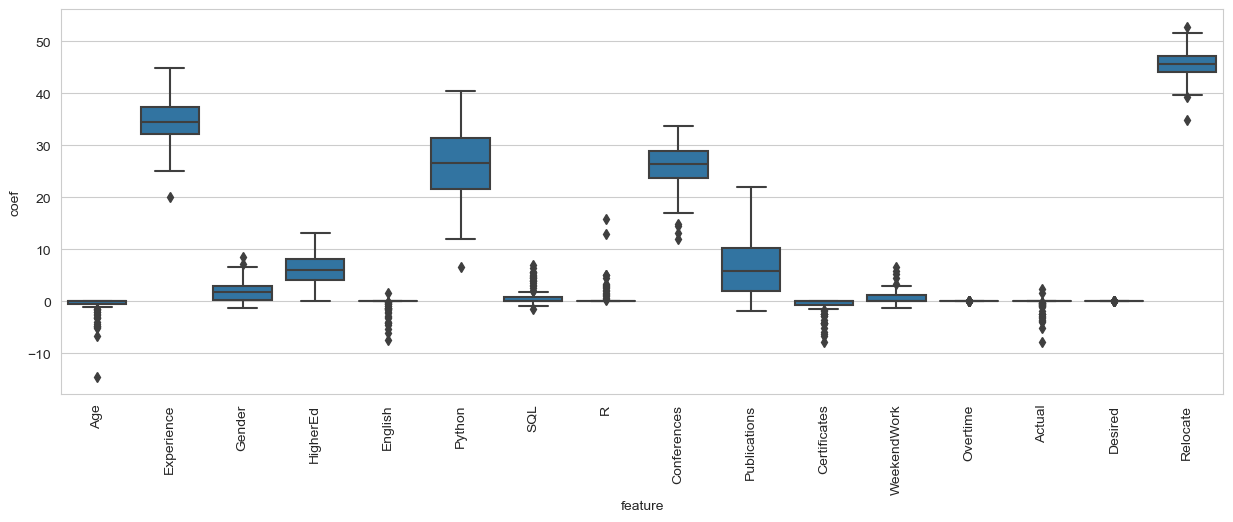

Age            -8.082823e-01
Experience      3.443004e+01
Gender          1.960614e+00
HigherEd        5.797678e+00
English        -6.002260e-01
Python          2.574850e+01
SQL             8.947419e-01
R               6.829589e-01
Conferences     2.589982e+01
Publications    6.400766e+00
Certificates   -8.346875e-01
WeekendWork     7.809098e-01
Overtime        5.761021e-16
Actual         -4.598920e-01
Desired        -3.436527e-03
Relocate        4.555727e+01
dtype: float64


In [9]:
X = df.drop(columns = ['Target'])
y = df['Target']

coef_lasso = pd.DataFrame(columns = X.columns)

for k in range(100):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=k)
    
    scaler = MinMaxScaler()
    scaler.fit(X_train)

    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
    
    lasso = Lasso(max_alpha_lasso)
    lasso.fit(X_train, y_train)

    coef_lasso.loc[k] = lasso.coef_

coef_long_lasso = pd.DataFrame(columns = ['feature', 'coef'])
for col in coef_lasso.columns:
    d = pd.DataFrame(columns = ['feature', 'coef'])
    d['feature'] = [col]*len(coef_lasso)
    d['coef'] = coef_lasso[col]
    coef_long_lasso = pd.concat([coef_long_lasso, d], ignore_index=True)
    
plt.figure(figsize=(15, 5))
sns.boxplot(data=coef_long_lasso, x='feature', y='coef', color = 'C0')
plt.xticks(rotation=90)
plt.show()

print(coef_lasso.mean())

С точки зрения решения нашей бизнес-задачи, результаты получились точно такие же. Однако, в целом интерпретация коэффициентов здесь сложнее. Готовность к переработке — ушла в точный 0. Понятно, почему так произошло: потому что это Lasso. Не понятно, как интерпретировать тот факт, что готовность работать в выходные отличаестя от готовности к переработкам (дело в том, что это два одинаковых столбца). Еще — странно, что возраст из очевидного минуса превратился примерно в 0.

В общем, вывод. Если важна интерпретация коэффициентов — нужен ридж. Если нужно избавиться от незначимых предикторов — нужно лассо.

## Домашнее задание

>#### Задание 1
Прочитайте файл `marketing.csv`

In [10]:
df = pd.read_csv('data/marketing.csv')
df

,AdBudget,ChannelsCount,LeadScoreThreshold,EmailFollowUps,DemoRequests,AvgTimeOnSite,PagesPerSession,ContentPieces,TestRatio,RetargetingShare,OrganicShare,CAC,LeadVolume,SaleCycleDays,WeekendPosts,ConversionRate
0,137.45,4,35,2,2,82.89,5.52,1,0.7442,0.9803,0.1794,75,41,1.93,149,77
1,195.07,3,64,0,0,75.72,5.04,5,0.7209,0.0753,0.1102,38,48,2.30,134,23
2,173.20,2,37,4,4,54.70,3.65,5,0.3081,0.3057,0.2773,47,74,1.10,122,60
3,159.87,5,66,9,9,110.11,7.33,1,0.5425,0.1909,0.1055,77,22,2.90,116,89
4,115.60,5,72,6,6,102.72,6.85,3,0.5088,0.2685,0.2158,74,31,2.77,125,55
5,115.60,4,43,9,9,133.87,8.92,1,0.6363,0.4853,0.1877,45,45,1.52,107,84
6,105.81,3,45,8,8,70.41,4.71,1,0.2505,0.3727,0.2344,56,35,1.03,128,66
7,186.62,2,44,6,6,66.62,4.44,2,0.5899,0.3947,0.1656,45,70,2.87,125,71
8,160.11,4,79,8,8,55.24,3.68,3,0.9789,0.8442,0.1310,72,56,2.00,109,92
9,170.81,3,79,7,7,62.81,4.19,3,0.4867,0.9300,0.2964,42,41,2.08,125,39


#### Контекст

B2B-компании, которая продаёт SaaS-продукт для автоматизации бизнес-процессов. Задача маркетолога — привлекать лидов, которые в итоге конвертируются в продажи. У него есть набор инструментов и каналов, он управляю бюджетом, контентом, таргетингом. Но он не до конца понимает, что именно реально двигает итоговую конверсию. 

У него есть данные за последние 12 месяцев по каждой кампании.


#### Предикторы

- AdBudget — бюджет на рекламную кампанию (тыс. руб.) (float),
- ChannelsCount — количество одновременно задействованных каналов (контекст, таргет, SEO, email, партнёрки) (int),
- LeadScoreThreshold — минимальный балл лида для передачи в продажи (0–100) (int)
- EmailFollowUps — количество касаний по email после скачивания материала (int),
- DemoRequests — количество запросов на демо-презентацию продукта (за кампанию) (int),
- AvgTimeOnSite — среднее время на сайте у лидов (сек) (float),
- PagesPerSession — среднее количество страниц за сессию (float),
- ContentPieces — количество созданных материалов под кампанию (статьи, кейсы, вебинары) (int),
- TestRatio — доля A/B-тестов среди всех креативов (float),
- RetargetingShare — доля бюджета, ушедшая на ретаргетинг (float),
- OrganicShare — доля трафика из органического поиска (float),
- CAC — стоимость привлечения одного лида (float),
- LeadVolume — общее количество лидов за период	(int),
- SaleCycleDays — средняя длина цикла сделки (дни) (float),
- WeekendPosts — количество постов в соцсетях, опубликованных в выходные (int).

#### Таргет

- ConversionRate — конверсия из лида в оплаченную сделку, в процентах (int).

#### Бизнес-задача

Понять, какие именно действия и параметры кампаний реально влияют на конверсию в продажи.

- Стоит ли гнаться за большим объёмом лидов (LeadVolume), или важнее качество и прогрев (LeadScoreThreshold, EmailFollowUps)?
- Оправдывает ли себя ретаргетинг (RetargetingShare)? Или это просто сжигание бюджета?
- Влияют ли «украшательства» вроде постов по выходным (WeekendPosts) на итоговую конверсию, или это пустая трата времени?
- Что важнее — количество каналов (ChannelsCount) или глубина проработки одного канала (например, ContentPieces)?